# Lab 5

In [2]:
from numpy.random import multivariate_normal
import matplotlib.pyplot as plt 
import numpy as np

## Ex 1

### 1.1

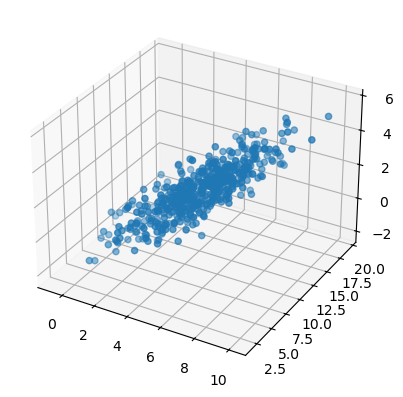

In [4]:
mean = [5, 10, 2]
cov = [[3, 2, 2], [2, 10, 1], [2, 1, 2]]

X = multivariate_normal(mean, cov, size=500)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:, 0], X[:, 1], X[:, 2])
plt.show()

mean_X = np.mean(X, axis=0)
X_centered = X - mean_X

cov_matrix = np.cov(X_centered, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]


### 1.2

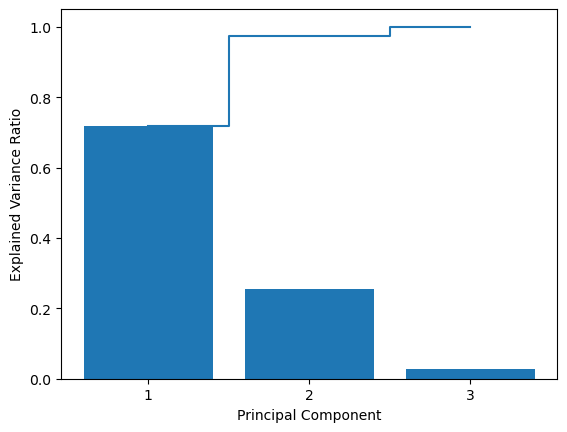

In [5]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

bins = [1, 2, 3]

plt.figure()
plt.bar(bins, explained_variance_ratio)
plt.step(bins, cumulative_explained_variance,where='mid')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(bins)
plt.show()



### 1.3

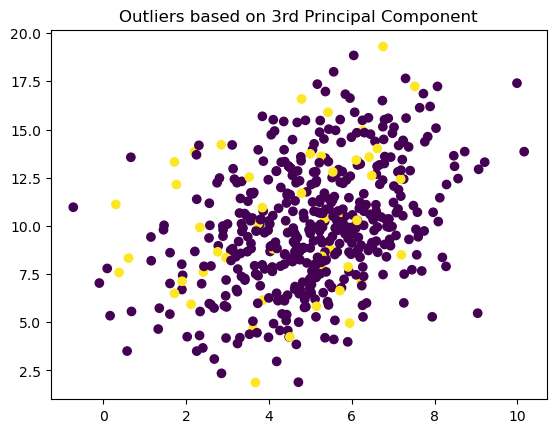

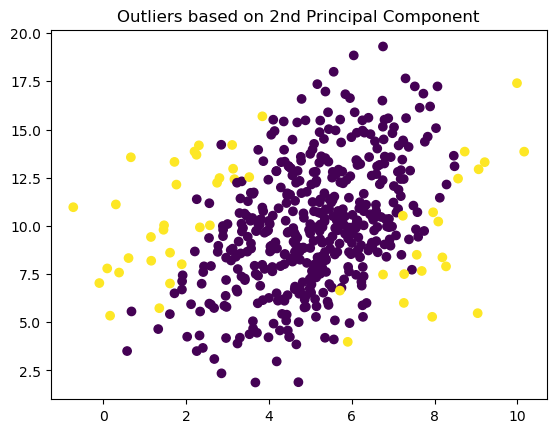

In [6]:
X_pca = X_centered @ eigenvectors

contamination = 0.1

pc3 = X_pca[:, 2]
pc3_dev = np.abs(pc3 - np.mean(pc3))
threshold_pc3 = np.quantile(pc3_dev, 1 - contamination)
labels_pc3 = pc3_dev > threshold_pc3

plt.scatter(X[:, 0], X[:, 1], c=labels_pc3)
plt.title('Outliers based on 3rd Principal Component')
plt.show()


pc2 = X_pca[:, 1]
pc2_dev = np.abs(pc2 - np.mean(pc2))
threshold_pc2 = np.quantile(pc2_dev, 1 - contamination)
labels_pc2 = pc2_dev > threshold_pc2

plt.scatter(X[:, 0], X[:, 1], c=labels_pc2)
plt.title('Outliers based on 2nd Principal Component')
plt.show()



### 1.4

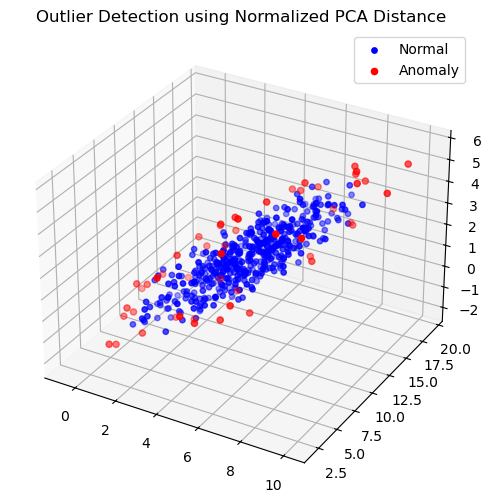

In [9]:

centroid = np.mean(X_pca, axis=0)
std_pca = np.std(X_pca, axis=0)

normalized_distances = np.sqrt(np.sum(((X_pca - centroid) / std_pca) ** 2, axis=1))

threshold = np.quantile(normalized_distances, 1 - contamination)

labels = (normalized_distances > threshold).astype(int)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[labels == 0, 0], X[labels == 0, 1], X[labels == 0, 2], c='blue', s=15, label='Normal')
ax.scatter(X[labels == 1, 0], X[labels == 1, 1], X[labels == 1, 2], c='red', s=20, label='Anomaly')

ax.set_title("Outlier Detection using Normalized PCA Distance")
plt.legend()
plt.show()


## Ex 2

### 2.1

Training contamination rate: 0.07149404216315307


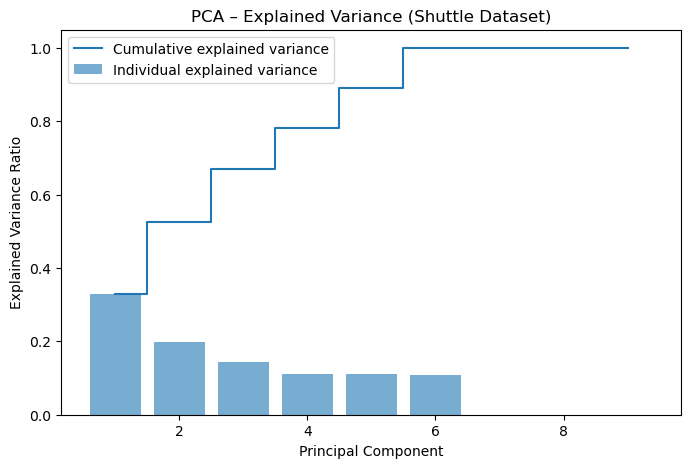

PCA Results:
Balanced Accuracy (Train): 0.9746859206385365
Balanced Accuracy (Test):  0.9739297121407451


In [4]:
from pyod.models.pca import PCA
from pyod.models.kpca import KPCA

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score
from scipy.io import loadmat


data = loadmat("shuttle.mat")
X = data["X"]
y = data["y"]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.4, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

contamination = np.mean(y_train)
print(f"Training contamination rate: {contamination}")

pca = PCA(contamination=contamination)
pca.fit(X_train_scaled)

explained_variance = pca.explained_variance_
explained_variance_ratio = explained_variance / np.sum(explained_variance)
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.6, label='Individual explained variance')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Cumulative explained variance')

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA – Explained Variance (Shuttle Dataset)")
plt.legend()
plt.show()


y_train_pred_pca = pca.predict(X_train_scaled)
train_bal_acc_pca = balanced_accuracy_score(y_train, y_train_pred_pca)

y_test_pred_pca = pca.predict(X_test_scaled)
test_bal_acc_pca = balanced_accuracy_score(y_test, y_test_pred_pca)

print("PCA Results:")
print(f"Balanced Accuracy (Train): {train_bal_acc_pca}")
print(f"Balanced Accuracy (Test):  {test_bal_acc_pca}")



### 2.2

In [5]:
kpca = KPCA(contamination=contamination, kernel='rbf')

kpca.fit(X_train_scaled)

y_train_pred_kpca = kpca.predict(X_train_scaled)
train_bal_acc_kpca = balanced_accuracy_score(y_train, y_train_pred_kpca)

y_test_pred_kpca = kpca.predict(X_test_scaled)
test_bal_acc_kpca = balanced_accuracy_score(y_test, y_test_pred_kpca)

print("KPCA Results:")
print(f"Balanced Accuracy (Train): {train_bal_acc_kpca}")
print(f"Balanced Accuracy (Test):  {test_bal_acc_kpca}")


KPCA Results:
Balanced Accuracy (Train): 0.6252749161189437
Balanced Accuracy (Test):  0.7671443365636044


## Ex 3

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0214 - val_loss: 0.0203
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0201 - val_loss: 0.0191
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0188 - val_loss: 0.0179
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0176 - val_loss: 0.0167
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0163 - val_loss: 0.0154
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0150 - val_loss: 0.0141
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0136 - val_loss: 0.0127
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0124 - val_loss: 0.0113
Epoch 9/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0109 - val_loss: 0.0100
Epoch 10/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0097 - val_loss: 0.0089
Epoch 11/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0086 - val_loss: 0.0079
Epoch 12/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0

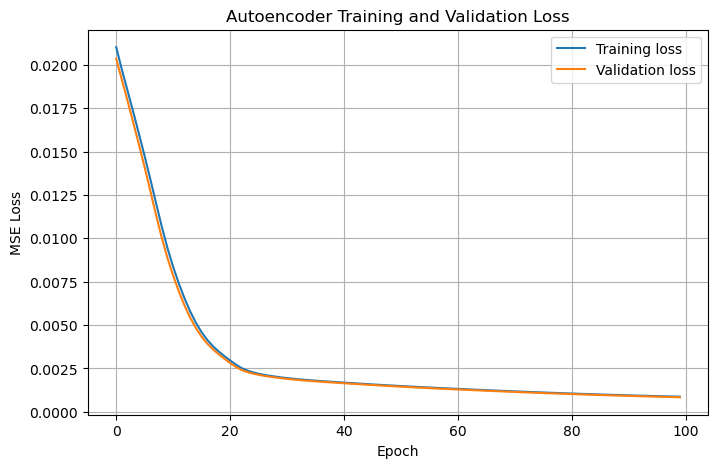

768/768 ━━━━━━━━━━━━━━━━━━━━ 0s 423us/step
Balanced Accuracy (Train): 0.7533
768/768 ━━━━━━━━━━━━━━━━━━━━ 0s 433us/step
Balanced Accuracy (Test):  0.7575


In [8]:
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

data = loadmat("shuttle.mat")

X = data["X"]
y = data["y"].ravel()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y, random_state=42)


scaler = MinMaxScaler(feature_range=(0, 1))

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

class Autoencoder(keras.Model):
    def __init__(self):
        super(Autoencoder, self).__init__()

        self.encoder = keras.Sequential([
            layers.Dense(8, activation='relu'),
            layers.Dense(5, activation='relu'),
            layers.Dense(3, activation='relu')
        ])

        self.decoder = keras.Sequential([
            layers.Dense(5, activation='relu'),
            layers.Dense(8, activation='relu'),
            layers.Dense(9, activation='sigmoid')
        ])

    def call(self, inputs):
        encoded = self.encoder(inputs)
        decoded = self.decoder(encoded)
        return decoded


autoencoder = Autoencoder()

autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

history = autoencoder.fit(
    X_train_scaled,
    X_train_scaled,
    epochs=100,
    batch_size=1024,
    validation_data=(X_test_scaled, X_test_scaled),
    shuffle=True,
    verbose=1
)

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training and Validation Loss")
plt.legend()
plt.show()


# acc for train data
X_train_recon = autoencoder.predict(X_train_scaled)
train_errors = np.mean(np.square(X_train_scaled - X_train_recon), axis=1)

contamination = np.mean(y_train)
threshold = np.quantile(train_errors, 1 - contamination)

y_train_pred = (train_errors > threshold).astype(int)

train_bal_acc = balanced_accuracy_score(y_train, y_train_pred)
print(f"Balanced Accuracy (Train): {train_bal_acc:.4f}")


# acc for test data
X_test_recon = autoencoder.predict(X_test_scaled)
test_errors = np.mean(np.square(X_test_scaled - X_test_recon), axis=1)

y_test_pred = (test_errors > threshold).astype(int)

test_bal_acc = balanced_accuracy_score(y_test, y_test_pred)
print(f"Balanced Accuracy (Test):  {test_bal_acc:.4f}")



## Ex 4

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0784 - val_loss: 0.0092
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0079 - val_loss: 0.0044
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0043 - val_loss: 0.0037
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0038 - val_loss: 0.0035
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0036 - val_loss: 0.0034
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0034 - val_loss: 0.0030
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0028 - val_loss: 0.0023
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0023 - val_loss: 0.0022
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0021 - val_loss: 0.0020
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/

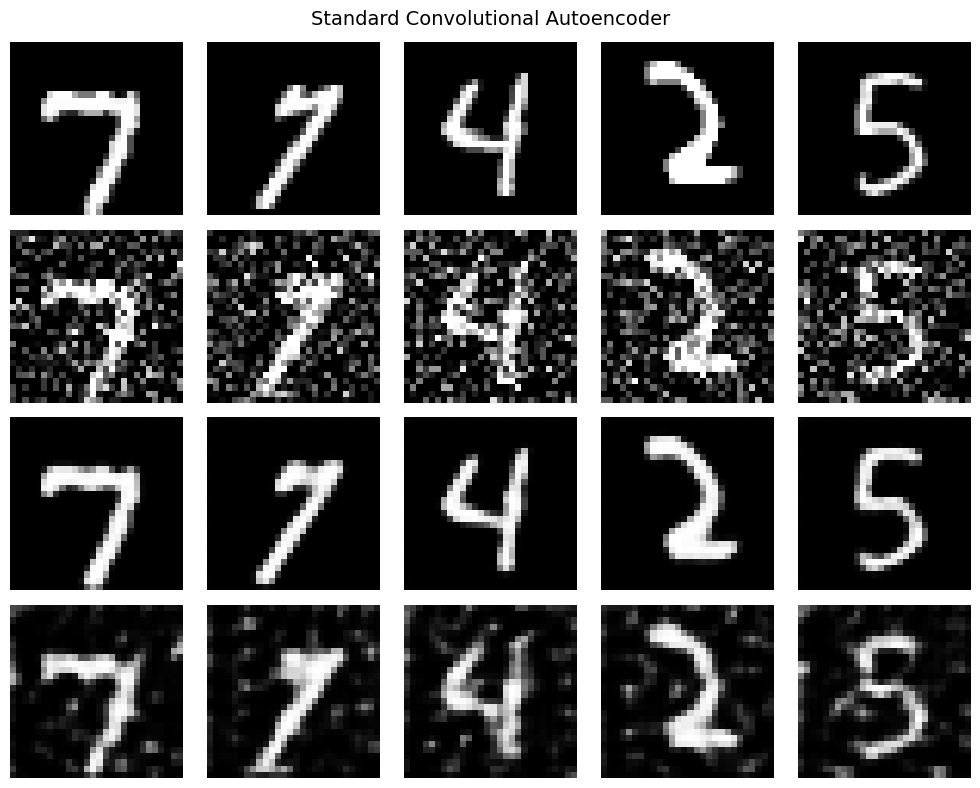

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1312 - val_loss: 0.1141
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1120 - val_loss: 0.1141
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1121 - val_loss: 0.1141
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1117 - val_loss: 0.1141
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1118 - val_loss: 0.1141
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1123 - val_loss: 0.1141
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1121 - val_loss: 0.1141
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1118 - val_loss: 0.1141
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1121 - val_loss: 0.1141
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1119 - val_loss: 0.1141
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


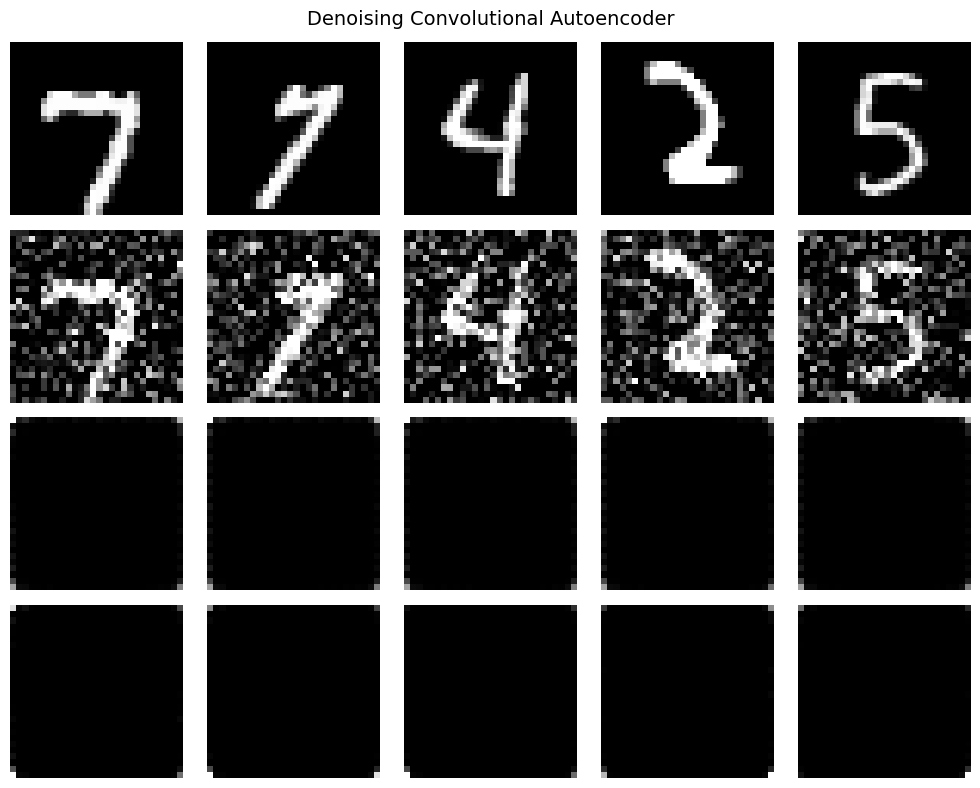

In [9]:
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

noise_factor = 0.35

x_test_noisy = x_test + noise_factor * tf.random.normal(shape=x_test.shape)
x_test_noisy = tf.clip_by_value(x_test_noisy, 0.0, 1.0)

class ConvAutoencoder(keras.Model):
    def __init__(self):
        super(ConvAutoencoder, self).__init__()

        self.encoder = keras.Sequential([
            layers.Conv2D(8, (3, 3), activation='relu', strides=2, padding='same'),
            layers.Conv2D(4, (3, 3), activation='relu', strides=2, padding='same')
        ])

        self.decoder = keras.Sequential([
            layers.Conv2DTranspose(4, (3, 3), activation='relu', strides=2, padding='same'),
            layers.Conv2DTranspose(8, (3, 3), activation='relu', strides=2, padding='same'),
            layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')
        ])

    def call(self, inputs):
        encoded = self.encoder(inputs)
        decoded = self.decoder(encoded)
        return decoded

autoencoder = ConvAutoencoder()

autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

history = autoencoder.fit(
    x_train,
    x_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, x_test),
    shuffle=True,
    verbose=1
)


x_train_recon = autoencoder.predict(x_train)
train_errors = np.mean(np.square(x_train - x_train_recon), axis=(1, 2, 3))

threshold = np.mean(train_errors) + np.std(train_errors)

x_test_recon = autoencoder.predict(x_test)
test_errors = np.mean(np.square(x_test - x_test_recon),axis=(1, 2, 3))

y_test_pred = test_errors < threshold
accuracy_original = np.mean(y_test_pred)

x_test_noisy_recon = autoencoder.predict(x_test_noisy)
test_noisy_errors = np.mean(np.square(x_test_noisy - x_test_noisy_recon), axis=(1, 2, 3))

y_noisy_pred = test_noisy_errors > threshold
accuracy_noisy = np.mean(y_noisy_pred)

print(f"Accuracy on original test images: {accuracy_original:.4f}")
print(f"Accuracy on noisy test images:     {accuracy_noisy:.4f}")


n = 5
indices = np.random.choice(len(x_test), n, replace=False)

plt.figure(figsize=(10, 8))

for i, idx in enumerate(indices):
    plt.subplot(4, n, i + 1)
    plt.imshow(x_test[idx].squeeze(), cmap='gray')
    plt.axis('off')

    plt.subplot(4, n, i + 1 + n)
    plt.imshow(x_test_noisy[idx].numpy().squeeze(), cmap='gray')
    plt.axis('off')

    plt.subplot(4, n, i + 1 + 2 * n)
    plt.imshow(x_test_recon[idx].squeeze(), cmap='gray')
    plt.axis('off')

    plt.subplot(4, n, i + 1 + 3 * n)
    plt.imshow(x_test_noisy_recon[idx].squeeze(), cmap='gray')
    plt.axis('off')

plt.suptitle("Standard Convolutional Autoencoder", fontsize=14)
plt.tight_layout()
plt.show()


x_train_noisy = x_train + noise_factor * tf.random.normal(shape=x_train.shape)
x_train_noisy = tf.clip_by_value(x_train_noisy, 0.0, 1.0)

denoising_autoencoder = ConvAutoencoder()
denoising_autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

denoising_autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test_noisy, x_test),
    shuffle=True,
    verbose=1
)


x_test_recon_denoised = denoising_autoencoder.predict(x_test)
x_test_noisy_recon_denoised = denoising_autoencoder.predict(x_test_noisy)


plt.figure(figsize=(10, 8))

for i, idx in enumerate(indices):
    plt.subplot(4, n, i + 1)
    plt.imshow(x_test[idx].squeeze(), cmap='gray')
    plt.axis('off')

    plt.subplot(4, n, i + 1 + n)
    plt.imshow(x_test_noisy[idx].numpy().squeeze(), cmap='gray')
    plt.axis('off')

    plt.subplot(4, n, i + 1 + 2 * n)
    plt.imshow(x_test_recon_denoised[idx].squeeze(), cmap='gray')
    plt.axis('off')

    plt.subplot(4, n, i + 1 + 3 * n)
    plt.imshow(x_test_noisy_recon_denoised[idx].squeeze(), cmap='gray')
    plt.axis('off')

plt.suptitle("Denoising Convolutional Autoencoder", fontsize=14)
plt.tight_layout()
plt.show()


